# Lab 10

By Niksh Hiremath (U20240158)

## 1. Code

### Importing libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

In [2]:
np.random.seed(0)

### Generating synthetic data

In [3]:
N_SAMPLES = 500

mu1 = [2, 2]
sigma1 = [[0.9, -0.0255], [-0.0255, 0.9]]

mu2 = [5, 5]
sigma2 = [[0.5, 0], [0, 0.3]]

In [ ]:
samples1 = np.random.multivariate_normal(mu1, sigma1, N_SAMPLES // 2)
samples2 = np.random.multivariate_normal(mu2, sigma2, N_SAMPLES // 2)

# Labels: 0 for Class 1, 1 for Class 2
labels1 = np.zeros(N_SAMPLES // 2)
labels2 = np.ones(N_SAMPLES // 2)

### Combining distributions and labels

In [5]:
X = np.vstack([samples1, samples2])
y = np.hstack([labels1, labels2])

### Adding bias term

In [ ]:
# Bias = 1
X_bias = np.hstack([np.ones((X.shape[0], 1)), X])

### Splitting the dataset

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bias,
    y,
    test_size=0.2,
    random_state=0,
)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((400, 3), (400,), (100, 3), (100,))

### Perceptron implementation

In [8]:
def step_activation(activation):
    return 1 if activation >= 0 else 0

In [9]:
def train_perceptron(X, y, learning_rate=0.1, max_epochs=1000):
    weights = np.zeros(X.shape[1])

    for epoch in range(max_epochs):
        errors = 0
        for xi, yi in zip(X, y):
            activation = np.dot(weights, xi)
            y_pred = step_activation(activation)
            error = yi - y_pred
            weights += learning_rate * error * xi
            if error != 0:
                errors += 1
        if errors == 0:  # Early stopping
            print(f"Converged at epoch {epoch + 1}")
            break

    return weights

### Training the perceptron

In [10]:
LEARNING_RATE = 0.1
MAX_EPOCHS = 1000

weights = train_perceptron(
    X_train,
    y_train,
    learning_rate=LEARNING_RATE,
    max_epochs=MAX_EPOCHS,
)
print(f"Learned weights: {weights}")

Converged at epoch 4
Learned weights: [-3.5         0.45644901  0.50921035]


### Making predictions on the test set

In [11]:
def predict(X, weights):
    return np.array([step_activation(np.dot(weights, xi)) for xi in X])

In [12]:
y_pred = predict(X_test, weights)

accuracy = np.mean(y_pred == y_test)
print(f"Test Accuracy: {accuracy:.2%}")

Test Accuracy: 100.00%


### Plotting decision boundary

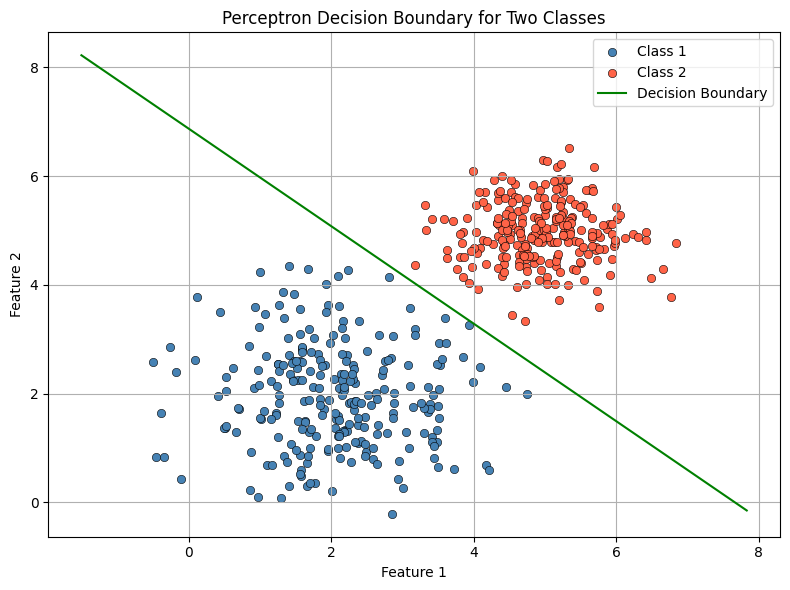

In [13]:
X_plot = X_bias[:, 1:]

plt.figure(figsize=(8, 6))

plt.scatter(
    X_plot[y == 0, 0],
    X_plot[y == 0, 1],
    label="Class 1",
    color="steelblue",
    edgecolors="k",
    linewidths=0.4,
)
plt.scatter(
    X_plot[y == 1, 0],
    X_plot[y == 1, 1],
    label="Class 2",
    color="tomato",
    edgecolors="k",
    linewidths=0.4,
)

x1_range = np.linspace(X_plot[:, 0].min() - 1, X_plot[:, 0].max() + 1, 200)
x2_boundary = -(weights[0] + weights[1] * x1_range) / weights[2]

plt.plot(x1_range, x2_boundary, color="green", label="Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Perceptron Decision Boundary for Two Classes")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Plotting confusion matrix

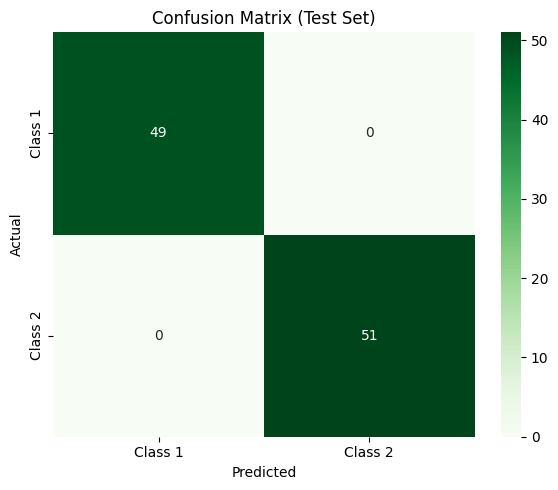

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Class 1", "Class 2"],
    yticklabels=["Class 1", "Class 2"],
)

plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## 2. Report

### Q1: What are the parallels between Biological NNs and Artificial NNs? List any three.

**Ans:**

- Both have neurons connected to each other and pass signals.

- Both adjust strength of connections (weights in CNNs, synapse in Bio NN).

- Both function through layers.

---


### Q2: What was the McCulloch-Pitts Neuron model? List any two of its limitations.

**Ans:**

It is a simple neuron model that gives output as 0 or 1 based on a threshold.

**Limitations:**

- It cannot learn.

- It only works for simple (linear) problems.

---


### Q3: How does a perceptron learn?

**Ans:**

- A perceptron learns by updating its weights based on the errors it makes during training. 

- It uses the formula `w = w + learning_rate * error * x` to adjust the weights. 

- The learning process involves iterating through the training samples, computing predictions, calculating errors, and updating weights until convergence or a maximum number of epochs is reached.

---


### Q4: List any three activation functions and their respective output ranges.

**Ans:**

- **Step Function:** Output range: {0, 1}

- **Sigmoid Function:** Output range: (0, 1)

- **ReLU (Rectified Linear Unit):** Output range: [0, ∞)

---


### Q5: Why was the classical perceptron not able to solve the XOR problem? Can you suggest a way to solve the XOR problem using neural networks but without going into a higher dimensional space?

**Ans:**

- Perceptron cannot solve XOR because data is not linearly separable. 

- We can solve it using a multi-layer neural network (adding hidden layer).

---
